# Retail Sales Prediction using Machine Learning

## Table of Contents

* **Section 1:** Imports
* **Section 2:** Load Dataset
* **Section 3:** Feature Engineering
* **Section 4:** Handle Missing Values
* **Section 5:** Encode Categorical Variables
* **Section 6:** Train-Test Split
* **Section 7:** Baseline Model - Linear Regression
* **Section 8:** Random Forest Regressor
* **Section 9:** XGBoost Regressor
* **Section 10:** Model Evaluation
* **Section 11:** Feature Importance Analysis
* **Section 12:** ML vs Time Series Comparison
* **Section 13:** Phase 4 Findings

In [1]:
# ============================================
# SECTION 1: IMPORTS
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import warnings
warnings.filterwarnings("ignore")

print("All imports successful!")

All imports successful!


In [2]:
# ============================================
# SECTION 2: LOAD DATASET
# ============================================

# Load datasets

train = pd.read_csv("../data/raw/train.csv")
store = pd.read_csv("../data/raw/store.csv")


# Display shape

print("Train Shape :", train.shape)
print("Store Shape :", store.shape)


# Display first few rows

display(train.head())

display(store.head())

Train Shape : (1017209, 9)
Store Shape : (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [3]:
# ============================================
# MERGE TRAIN AND STORE DATA
# ============================================

# Merge using Store column

df = train.merge(
    store,
    how="left",
    on="Store"
)


print("Merged Dataset Shape:", df.shape)


# Display merged data

display(df.head())

Merged Dataset Shape: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
# View columns

df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='str')

In [5]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionOpenSinceYea

In [ ]:
# Missing values

missing = df.isnull().sum()

missing[missing > 0].sort_values(
    ascending=False
)       

Promo2SinceYear              508031
Promo2SinceWeek              508031
PromoInterval                508031
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
CompetitionDistance            2642
dtype: int64

In [7]:
# ============================================
# SECTION 3: DATA PREPARATION
# ============================================


# --------------------------------------------
# Convert Date column to datetime
# --------------------------------------------

df["Date"] = pd.to_datetime(df["Date"])


# Check datatype

print(df["Date"].dtype)

datetime64[us]


In [8]:
# --------------------------------------------
# Extract date-based features
# --------------------------------------------

df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Day"] = df["Date"].dt.day

df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)


# Display new features

df[
    [
        "Date",
        "Year",
        "Month",
        "Day",
        "WeekOfYear"
    ]
].head()

,Date,Year,Month,Day,WeekOfYear
0,2015-07-31,2015,7,31,31
1,2015-07-31,2015,7,31,31
2,2015-07-31,2015,7,31,31
3,2015-07-31,2015,7,31,31
4,2015-07-31,2015,7,31,31


In [9]:
# --------------------------------------------
# Handle Competition Distance
# --------------------------------------------

df["CompetitionDistance"] = (
    df["CompetitionDistance"]
    .fillna(
        df["CompetitionDistance"].median()
    )
)

In [10]:
# --------------------------------------------
# Competition opening information
# --------------------------------------------

competition_cols = [
    "CompetitionOpenSinceMonth",
    "CompetitionOpenSinceYear"
]


for col in competition_cols:
    df[col] = df[col].fillna(0)

In [11]:
# --------------------------------------------
# Promo2 information
# --------------------------------------------

promo_cols = [
    "Promo2SinceWeek",
    "Promo2SinceYear"
]


for col in promo_cols:
    df[col] = df[col].fillna(0)

In [12]:
# --------------------------------------------
# Promo interval
# --------------------------------------------

df["PromoInterval"] = (
    df["PromoInterval"]
    .fillna("None")
)

In [13]:
# Final missing value check

df.isnull().sum().sort_values(
    ascending=False
).head(10)

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
StoreType        0
dtype: int64

In [14]:
df.drop(
    "Date",
    axis=1,
    inplace=True
)

In [15]:
print(df.shape)

df.head()

(1017209, 21)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,5263,555,1,1,0,1,c,a,...,9.0,2008.0,0,0.0,0.0,None,2015,7,31,31
1,2,5,6064,625,1,1,0,1,a,a,...,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31
2,3,5,8314,821,1,1,0,1,a,a,...,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31
3,4,5,13995,1498,1,1,0,1,c,c,...,9.0,2009.0,0,0.0,0.0,None,2015,7,31,31
4,5,5,4822,559,1,1,0,1,a,a,...,4.0,2015.0,0,0.0,0.0,None,2015,7,31,31


In [24]:
# ============================================
# SECTION 4: FEATURE ENGINEERING
# ============================================


# ============================================
# 1. Competition Age
# ============================================

# Calculate how long a competitor has existed
# If no competitor information exists -> 0

df["CompetitionAge"] = np.where(
    df["CompetitionOpenSinceYear"] > 0,
    df["Year"] - df["CompetitionOpenSinceYear"],
    0
)


# ============================================
# 2. Promo2 Duration
# ============================================

# Calculate duration of Promo2 campaign
# If store never participated -> 0

df["Promo2Age"] = np.where(
    df["Promo2SinceYear"] > 0,
    df["Year"] - df["Promo2SinceYear"],
    0
)


# Prevent negative values

df["CompetitionAge"] = (
    df["CompetitionAge"]
    .clip(lower=0)
)

df["Promo2Age"] = (
    df["Promo2Age"]
    .clip(lower=0)
)


# ============================================
# 3. Weekend Indicator
# ============================================

# DayOfWeek:
# 1 = Monday
# 7 = Sunday

df["IsWeekend"] = np.where(
    df["DayOfWeek"] >= 6,
    1,
    0
)


# ============================================
# 4. Remove Closed Stores
# ============================================

# Closed stores have zero sales.
# They do not represent demand prediction cases.

df = df[df["Open"] == 1]


# ============================================
# 5. Remove Constant Columns
# ============================================

# After filtering, Open will always be 1.
# It provides no predictive information.

df.drop(
    "Open",
    axis=1,
    inplace=True
)


# ============================================
# Check Engineered Features
# ============================================

new_features = [
    "CompetitionAge",
    "Promo2Age",
    "IsWeekend"
]


display(
    df[new_features].head()
)


# Final dataset size

print("Final Shape:", df.shape)

,CompetitionAge,Promo2Age,IsWeekend
0,7.0,0.0,0
1,8.0,5.0,0
2,9.0,4.0,0
3,6.0,0.0,0
4,0.0,0.0,0


Final Shape: (844392, 24)


In [27]:
# Final dataset size

print("Final Shape:", df.shape)


# Feature statistics

df[new_features].describe()

Final Shape: (844392, 24)


,CompetitionAge,Promo2Age,IsWeekend
count,844392.000000,844392.000000,844392.000000
mean,3.565663,1.078272,0.174861
std,5.471940,1.617105,0.379848
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000
75%,6.000000,2.000000,0.000000
max,115.000000,6.000000,1.000000


In [29]:
# ============================================
# SECTION 5: CATEGORICAL ENCODING
# ============================================


from sklearn.preprocessing import LabelEncoder


# --------------------------------------------
# Categorical columns
# --------------------------------------------

categorical_cols = [
    "StateHoliday",
    "StoreType",
    "Assortment",
    "PromoInterval"
]


# --------------------------------------------
# Convert all categorical values to strings
# --------------------------------------------

# Prevent mixed datatype errors
# Example: 0 and 'a' existing together

for col in categorical_cols:
    
    df[col] = (
        df[col]
        .fillna("None")
        .astype(str)
    )


# --------------------------------------------
# Apply Label Encoding
# --------------------------------------------

label_encoders = {}

for col in categorical_cols:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(
        df[col]
    )
    
    label_encoders[col] = le


# --------------------------------------------
# Verify encoding
# --------------------------------------------

display(
    df[categorical_cols].head()
)


print(df[categorical_cols].dtypes)

,StateHoliday,StoreType,Assortment,PromoInterval
0,0,2,0,3
1,0,0,0,1
2,0,0,0,1
3,0,2,2,3
4,0,0,0,3


StateHoliday     int64
StoreType        int64
Assortment       int64
PromoInterval    int64
dtype: object


In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      844392 non-null  int64  
 1   DayOfWeek                  844392 non-null  int64  
 2   Sales                      844392 non-null  int64  
 3   Customers                  844392 non-null  int64  
 4   Promo                      844392 non-null  int64  
 5   StateHoliday               844392 non-null  int64  
 6   SchoolHoliday              844392 non-null  int64  
 7   StoreType                  844392 non-null  int64  
 8   Assortment                 844392 non-null  int64  
 9   CompetitionDistance        844392 non-null  float64
 10  CompetitionOpenSinceMonth  844392 non-null  float64
 11  CompetitionOpenSinceYear   844392 non-null  float64
 12  Promo2                     844392 non-null  int64  
 13  Promo2SinceWeek            844392 non-null  

In [31]:
# Remove constant feature

df.drop(
    "IsOpen",
    axis=1,
    inplace=True
)


print(df.shape)

(844392, 23)


In [33]:
# ============================================
# SECTION 6: FEATURE-TARGET SPLIT
# ============================================


# Target variable

target = "Sales"


# Remove target and leakage column

X = df.drop(
    [
        "Sales",
        "Customers"
    ],
    axis=1
)


y = df[target]


# Check dimensions

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (844392, 21)
Target Shape : (844392,)


In [34]:
# ============================================
# SECTION 7: TRAIN-TEST SPLIT
# ============================================


# Combine X and y temporarily
# Required for time-based splitting

model_data = X.copy()

model_data["Sales"] = y


# Sort chronologically

model_data = model_data.sort_values(
    by=["Year", "Month", "Day"]
)


# 80-20 time split

split_index = int(
    len(model_data) * 0.8
)


train_data = model_data.iloc[:split_index]

test_data = model_data.iloc[split_index:]


# Separate features and target again

X_train = train_data.drop(
    "Sales",
    axis=1
)

y_train = train_data["Sales"]


X_test = test_data.drop(
    "Sales",
    axis=1
)

y_test = test_data["Sales"]


# Check sizes

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (675513, 21)
X_test : (168879, 21)
y_train: (675513,)
y_test : (168879,)


In [35]:
# ============================================
# SECTION 8: BASELINE MODEL
# ============================================


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np


# Predict mean sales for every observation

baseline_prediction = np.full(
    shape=len(y_test),
    fill_value=y_train.mean()
)


# Evaluation

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_prediction
    )
)

baseline_mape = mean_absolute_percentage_error(
    y_test,
    baseline_prediction
) * 100


print("Baseline Model Performance")
print("--------------------------")
print("MAE :", baseline_mae)
print("RMSE:", baseline_rmse)
print("MAPE:", baseline_mape)

Baseline Model Performance
--------------------------
MAE : 2239.9373464607143
RMSE: 3070.0188171526547
MAPE: 5.531931167958021e+16


In [36]:
# ============================================
# SECTION 9: LINEAR REGRESSION MODEL
# ============================================


from sklearn.linear_model import LinearRegression


# Initialize model

lr_model = LinearRegression()


# Train model

lr_model.fit(
    X_train,
    y_train
)


# Predictions

lr_predictions = lr_model.predict(
    X_test
)


# Evaluation

lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)


lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_predictions
    )
)


# Safe MAPE

lr_mape = (
    np.mean(
        np.abs(
            (y_test - lr_predictions)
            /
            np.where(y_test == 0, 1, y_test)
        )
    )
    * 100
)


print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("MAPE:", lr_mape)

Linear Regression Performance
-----------------------------
MAE : 1991.761440749688
RMSE: 2761.1157882650828
MAPE: 42.30827069393542


In [37]:
# ============================================
# SECTION 10: RANDOM FOREST REGRESSOR
# ============================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Initialize model

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)


# Train

rf_model.fit(
    X_train,
    y_train
)


# Prediction

rf_pred = rf_model.predict(
    X_test
)


# Evaluation

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)


rf_mape = mean_absolute_percentage_error(
    y_test[y_test > 0],
    rf_pred[y_test > 0]
) * 100


print("Random Forest Performance")
print("-------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("MAPE:", rf_mape)

Random Forest Performance
-------------------------
MAE : 804.1689970383444
RMSE: 1190.3819672774316
MAPE: 11.432223945168731


,Feature,Importance
7,CompetitionDistance,0.200851
0,Store,0.166088
2,Promo,0.148338
8,CompetitionOpenSinceMonth,0.065254
9,CompetitionOpenSinceYear,0.064934
1,DayOfWeek,0.064750
17,WeekOfYear,0.040036
16,Day,0.032777
18,CompetitionAge,0.032710
12,Promo2SinceYear,0.032687


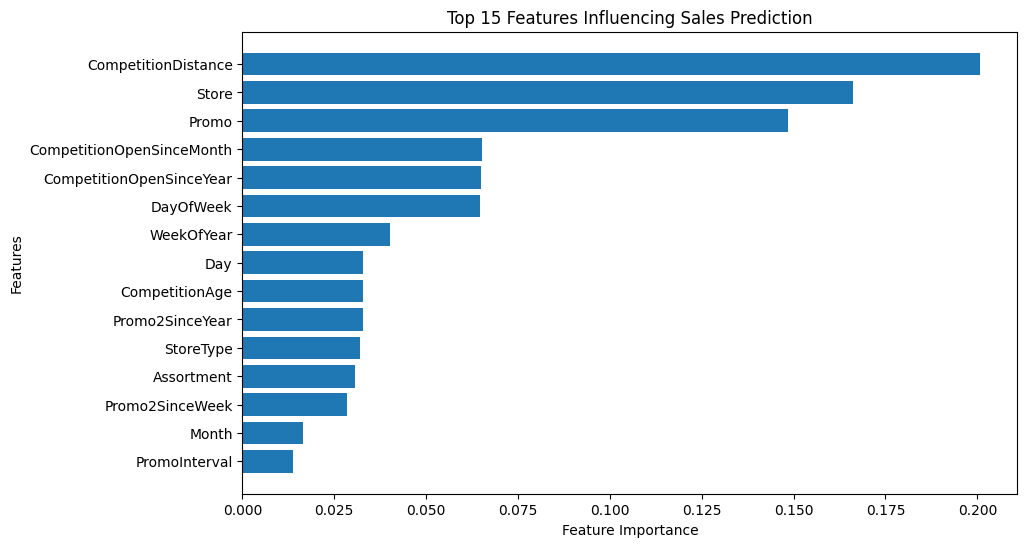

In [38]:
# ============================================
# SECTION 11: FEATURE IMPORTANCE ANALYSIS
# ============================================

import pandas as pd
import matplotlib.pyplot as plt


# Get feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})


# Sort values

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)


# Display top features

display(
    feature_importance.head(15)
)


# Plot

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance.head(15)["Feature"],
    feature_importance.head(15)["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 15 Features Influencing Sales Prediction"
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Features"
)

plt.show()

In [39]:
# ============================================
# SECTION 12: XGBOOST REGRESSOR
# ============================================

from xgboost import XGBRegressor


xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)


# Train

xgb_model.fit(
    X_train,
    y_train
)


# Prediction

xgb_pred = xgb_model.predict(
    X_test
)


# Evaluation

xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)


xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)


xgb_mape = mean_absolute_percentage_error(
    y_test[y_test > 0],
    xgb_pred[y_test > 0]
) * 100


print("XGBoost Performance")
print("-------------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("MAPE:", xgb_mape)

XGBoost Performance
-------------------
MAE : 792.7821655273438
RMSE: 1137.4129637031574
MAPE: 11.591318249702454


In [40]:
# ============================================
# SECTION 12: SAVE FINAL MODEL
# ============================================

import joblib
import os


# Create model directory

os.makedirs(
    "../models",
    exist_ok=True
)


# Save model

joblib.dump(
    xgb_model,
    "../models/xgboost_sales_forecaster.pkl"
)


print("Model saved successfully!")

Model saved successfully!


In [41]:
# ============================================
# SECTION 13: LOAD SAVED MODEL TEST
# ============================================

import joblib


loaded_model = joblib.load(
    "../models/xgboost_sales_forecaster.pkl"
)


# Predict using loaded model

test_prediction = loaded_model.predict(
    X_test.iloc[:5]
)


prediction_result = pd.DataFrame({
    "Actual Sales": y_test.iloc[:5].values,
    "Predicted Sales": test_prediction
})


prediction_result

,Actual Sales,Predicted Sales
0,5942,6579.844727
1,8423,8609.784180
2,7642,7046.028320
3,6338,6696.487305
4,9972,8763.070312


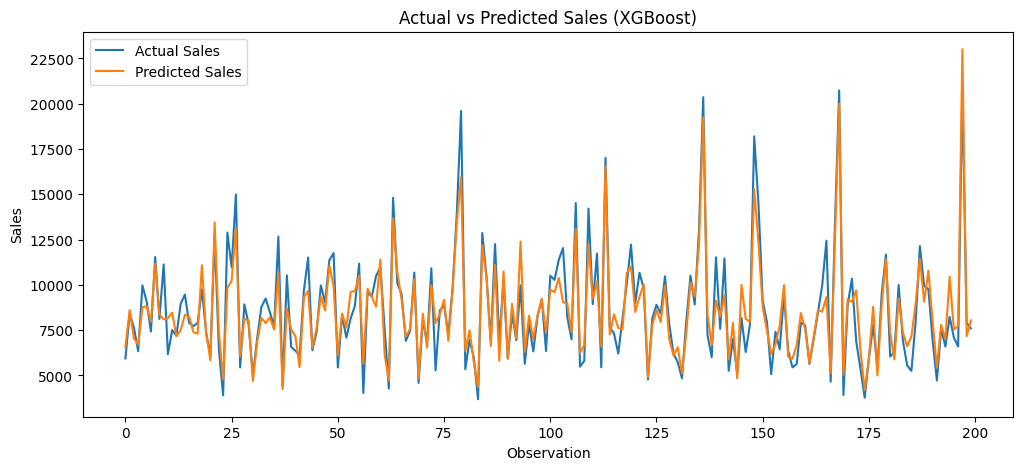

In [42]:
# ============================================
# SECTION 14: ACTUAL VS PREDICTED SALES
# ============================================


plt.figure(figsize=(12,5))


plt.plot(
    y_test.values[:200],
    label="Actual Sales"
)


plt.plot(
    xgb_pred[:200],
    label="Predicted Sales"
)


plt.title(
    "Actual vs Predicted Sales (XGBoost)"
)


plt.xlabel(
    "Observation"
)


plt.ylabel(
    "Sales"
)


plt.legend()

plt.show()

In [43]:
import joblib
import os


os.makedirs(
    "../models",
    exist_ok=True
)


joblib.dump(
    label_encoders,
    "../models/encoders.pkl"
)


print("Encoders saved successfully")

Encoders saved successfully
